### Monte Carlo Performance Benchmark: Django vs Gin

Kevin Geidel <br>
MSDS 436: Analytics Systems Engineering <br>
Northwestern University <br>
October 27, 2024 <br>

Execute the benchmark experiment on the Django framework & display results.

In [1]:
import django_init
from core.models import BenchmarkExperiment
import pandas as pd
pd.set_option('display.max_rows', None)

mc = BenchmarkExperiment()
mc.run_benchmark()
mc.results

,task_1_duration,task_1_results,task_2_duration,task_2_results,task_3_duration,task_3_results,total_microseconds
1,1331,8748064087735,3064,65.34%,9633,"{'X': 18210, 'O': 15000}",14028
2,606,8748002825136,821,65.34%,9274,"{'X': 18210, 'O': 15000}",10701
3,452,8748002733109,830,65.34%,11991,"{'X': 18210, 'O': 15000}",13273
4,1014,8748002922741,1101,65.34%,8919,"{'X': 18210, 'O': 15000}",11034
5,438,8748002733331,854,65.34%,14070,"{'X': 18210, 'O': 15000}",15362
6,483,8748002733454,749,65.34%,10332,"{'X': 18210, 'O': 15000}",11564
7,658,8748002733583,890,65.34%,9916,"{'X': 18210, 'O': 15000}",11464
8,550,8748002733718,1214,65.34%,9790,"{'X': 18210, 'O': 15000}",11554
9,470,8748002733850,852,65.34%,10224,"{'X': 18210, 'O': 15000}",11546
10,477,8748002733979,801,65.34%,10108,"{'X': 18210, 'O': 15000}",11386


In [2]:
stat_cols = [
    'task_1_duration', 'task_2_duration',
    'task_3_duration', 'total_microseconds'
]

for col in stat_cols:
    print("************************")
    print(col)
    print("************************")
    print(mc.results[col].describe())
    print('\n')

************************
task_1_duration
************************
count     100.0000
mean      543.3600
std       141.3125
min       435.0000
25%       468.0000
50%       498.5000
75%       563.2500
max      1331.0000
Name: task_1_duration, dtype: float64


************************
task_2_duration
************************
count     100.000000
mean      867.460000
std       278.604764
min       679.000000
25%       735.000000
50%       788.000000
75%       883.250000
max      3064.000000
Name: task_2_duration, dtype: float64


************************
task_3_duration
************************
count      100.000000
mean     10225.430000
std       3872.109279
min       8873.000000
25%       9292.000000
50%       9712.000000
75%      10181.750000
max      47205.000000
Name: task_3_duration, dtype: float64


************************
total_microseconds
************************
count      100.000000
mean     11636.250000
std       3869.686019
min      10015.000000
25%      10598.250000
50%    

Read in the data from the Go benchmark and display the results

In [3]:
go_results_file = '../go_benchmark/results.csv'

df = pd.read_csv(go_results_file, header=None)
df.columns = ['task_1_duration', 'task_2_duration', 'task_3_duration', 'total_microseconds']

df

,task_1_duration,task_2_duration,task_3_duration,total_microseconds
0,4800,4598,5199,14597
1,4607,4074,4939,13620
2,4386,4064,4741,13191
3,5650,4060,4700,14410
4,4225,4010,4664,12899
5,5226,4196,4509,13931
6,4430,4405,7385,16220
7,4245,4191,5631,14067
8,4249,4029,4650,12928
9,4245,4125,4473,12843


In [4]:
# Get stats for Go results
for col in df.columns:
    print("************************")
    print(col)
    print("************************")
    print(mc.results[col].describe())
    print('\n')

************************
task_1_duration
************************
count     100.0000
mean      543.3600
std       141.3125
min       435.0000
25%       468.0000
50%       498.5000
75%       563.2500
max      1331.0000
Name: task_1_duration, dtype: float64


************************
task_2_duration
************************
count     100.000000
mean      867.460000
std       278.604764
min       679.000000
25%       735.000000
50%       788.000000
75%       883.250000
max      3064.000000
Name: task_2_duration, dtype: float64


************************
task_3_duration
************************
count      100.000000
mean     10225.430000
std       3872.109279
min       8873.000000
25%       9292.000000
50%       9712.000000
75%      10181.750000
max      47205.000000
Name: task_3_duration, dtype: float64


************************
total_microseconds
************************
count      100.000000
mean     11636.250000
std       3869.686019
min      10015.000000
25%      10598.250000
50%    

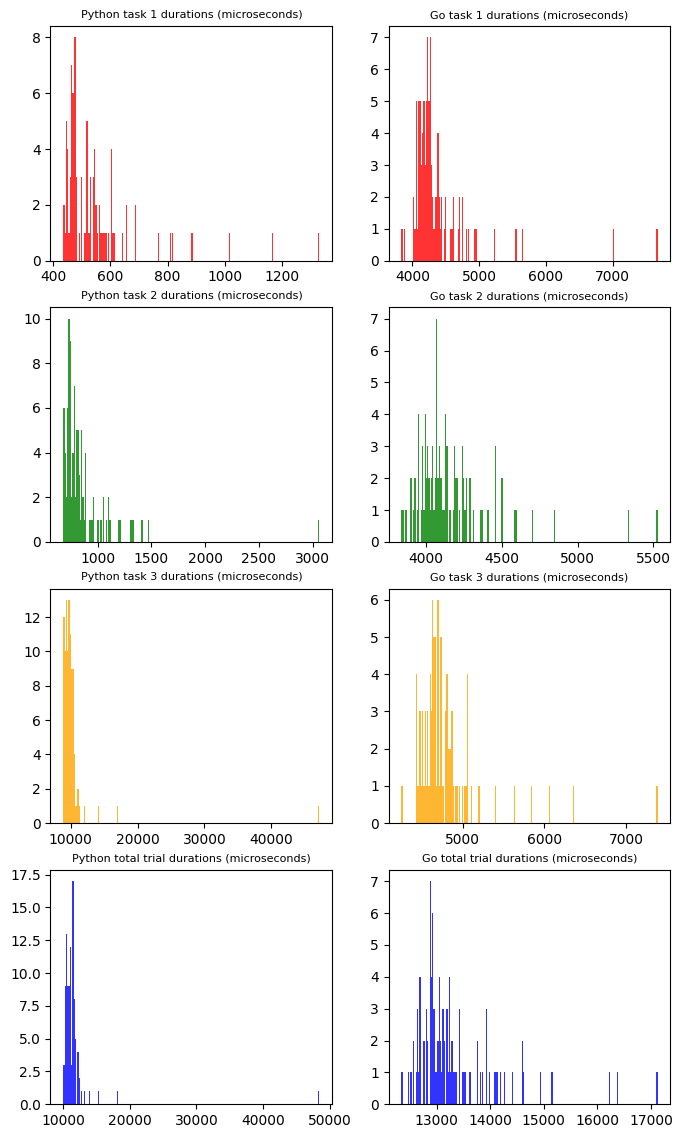

In [5]:
# Compare framework visually

import matplotlib.pyplot as plt

# Show the distribution of durations
fig, axs = plt.subplots(4, 2, figsize=(8,14))

################## PYTHON PLOTS ########################

axs[0][0].hist(
    mc.results['task_1_duration'], bins=200, 
    alpha=0.8, color='red',
);
axs[0][0].set_title('Python task 1 durations (microseconds)', fontsize=8)
axs[1][0].hist(
    mc.results['task_2_duration'], bins=200, 
    alpha=0.8, color='green', label = ''
);
axs[1][0].set_title('Python task 2 durations (microseconds)', fontsize=8)
axs[2][0].hist(
    mc.results['task_3_duration'], bins=200, 
    alpha=0.8, color='orange', label = ''
);
axs[2][0].set_title('Python task 3 durations (microseconds)', fontsize=8)
axs[3][0].hist(
    mc.results['total_microseconds'], bins=200, 
    alpha=0.8, color='blue', label = ''
);
axs[3][0].set_title('Python total trial durations (microseconds)', fontsize=8);

################## GO PLOTS ########################

axs[0][1].hist(
    df['task_1_duration'], bins=200, 
    alpha=0.8, color='red',
);
axs[0][1].set_title('Go task 1 durations (microseconds)', fontsize=8)
axs[1][1].hist(
    df['task_2_duration'], bins=200, 
    alpha=0.8, color='green', label = ''
);
axs[1][1].set_title('Go task 2 durations (microseconds)', fontsize=8)
axs[2][1].hist(
    df['task_3_duration'], bins=200, 
    alpha=0.8, color='orange', label = ''
);
axs[2][1].set_title('Go task 3 durations (microseconds)', fontsize=8)
axs[3][1].hist(
    df['total_microseconds'], bins=200, 
    alpha=0.8, color='blue', label = ''
);
axs[3][1].set_title('Go total trial durations (microseconds)', fontsize=8);

# fig.savefig('figure_1.png')